# Diabetes Prediction: Exploratory Data Analysis and Machine Learning

**Author:** Khadim Hussain
**Date:** October 2026

## Introduction
This notebook analyzes a public health dataset to understand which
medical measurements are linked to diabetes, and builds simple machine
learning models to predict whether a patient has diabetes.

## Dataset
The Pima Indians Diabetes Database contains 768 patient records with 8
medical measurements (such as glucose, BMI and age) and one target
column, `Outcome` (1 = diabetes, 0 = no diabetes). The data was
originally collected by the National Institute of Diabetes and
Digestive and Kidney Diseases and was accessed through Kaggle.

## Goals
1. Understand and clean the data
2. Explore patterns with charts
3. Train and compare prediction models
4. Evaluate the results and write conclusions

## 1. Loading the Data
We load the CSV file with pandas and check its size and first rows.

In [42]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Understanding the Data
We check the data types, missing values and basic statistics of each column.

In [43]:
df.info()
print()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3

## 3. Checking for Hidden Missing Values
Columns like Glucose, BloodPressure, SkinThickness, Insulin and BMI
cannot realistically be 0 for a living person. These zeros most likely
represent missing measurements, so we count them before cleaning.

In [44]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print((df[cols] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Observation:** No cell is technically empty, but many zeros are hidden
missing values. Insulin has 374 zeros (about 49% of rows) and
SkinThickness has 227 (about 30%). BloodPressure (35), BMI (11) and
Glucose (5) have far fewer. Zeros in Pregnancies are valid, so that
column is left unchanged.

## 4. Data Cleaning
We replace the impossible zeros with missing values (NaN) in a copy of
the data, so the original stays unchanged. The missing values will be
filled later inside the model pipeline, after splitting the data, to
avoid information from the test set leaking into training.

In [45]:
import numpy as np

df_clean = df.copy()
df_clean[cols] = df_clean[cols].replace(0, np.nan)

missing = df_clean.isna().sum()
missing_pct = (missing / len(df_clean) * 100).round(1)
print(pd.DataFrame({"missing": missing, "percent": missing_pct}))

                          missing  percent
Pregnancies                     0      0.0
Glucose                         5      0.7
BloodPressure                  35      4.6
SkinThickness                 227     29.6
Insulin                       374     48.7
BMI                            11      1.4
DiabetesPedigreeFunction        0      0.0
Age                             0      0.0
Outcome                         0      0.0


**Observation:** After replacing the zeros with NaN, Insulin (48.7%) and
SkinThickness (29.6%) are missing in large parts of the data, while
BloodPressure (4.6%), BMI (1.4%) and Glucose (0.7%) have only a few
missing values. We will fill these values later inside the model
pipeline.

## 5. Exploratory Data Analysis
First we look at how balanced the target variable (`Outcome`) is.

In [46]:
print(df["Outcome"].value_counts())
print()
print((df["Outcome"].value_counts(normalize=True) * 100).round(1))

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


**Observation:** The target is moderately imbalanced: 500 patients
(65.1%) do not have diabetes and 268 (34.9%) do. A model that always
predicts "no diabetes" would already reach 65.1% accuracy, so accuracy
alone is not a reliable measure here. We will also report precision,
recall and F1-score, and we use a stratified train/test split so both
parts keep the same class ratio.

### 5.1 Distribution of each feature
We compare the distribution of every measurement for patients with and
without diabetes. Densities are used so that the different group sizes
do not distort the comparison.

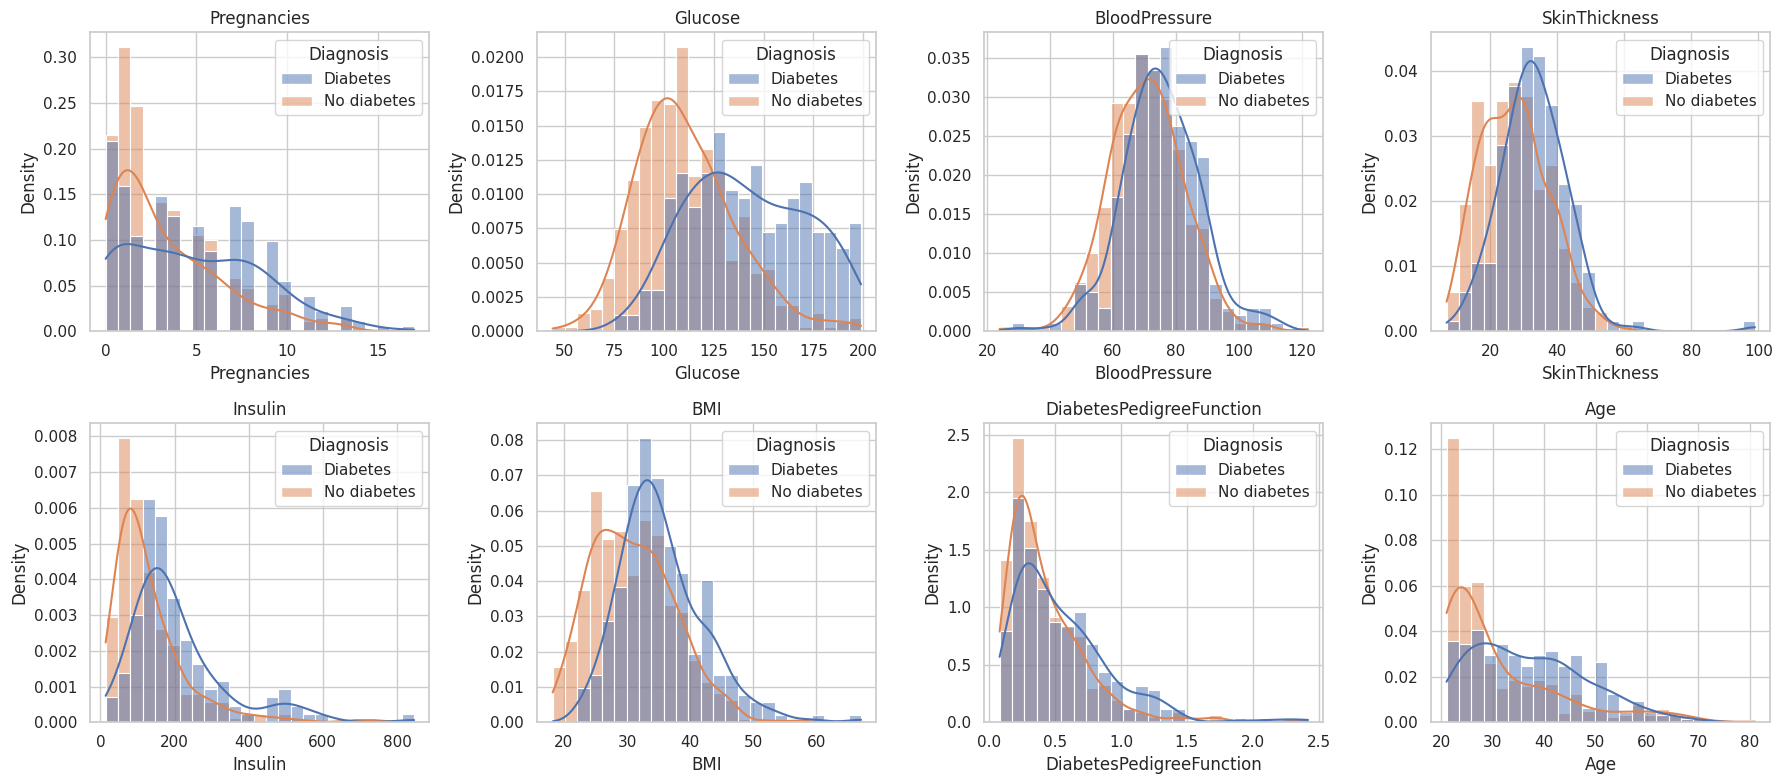

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_df = df_clean.assign(
    Diagnosis=df_clean["Outcome"].map({0: "No diabetes", 1: "Diabetes"})
)
features = [c for c in df_clean.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(data=plot_df, x=col, hue="Diagnosis", stat="density",
                 common_norm=False, kde=True, bins=25, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** Glucose shows the clearest separation between the two
groups: patients with diabetes tend to have higher glucose values.
Insulin, BMI and Age also shift towards higher values in the diabetes
group. BloodPressure looks very similar in both groups. Several
features (Insulin, Age, DiabetesPedigreeFunction) are right-skewed.

### 5.2 Features compared by diagnosis
Box plots show the median and spread of each measurement for the two
groups.

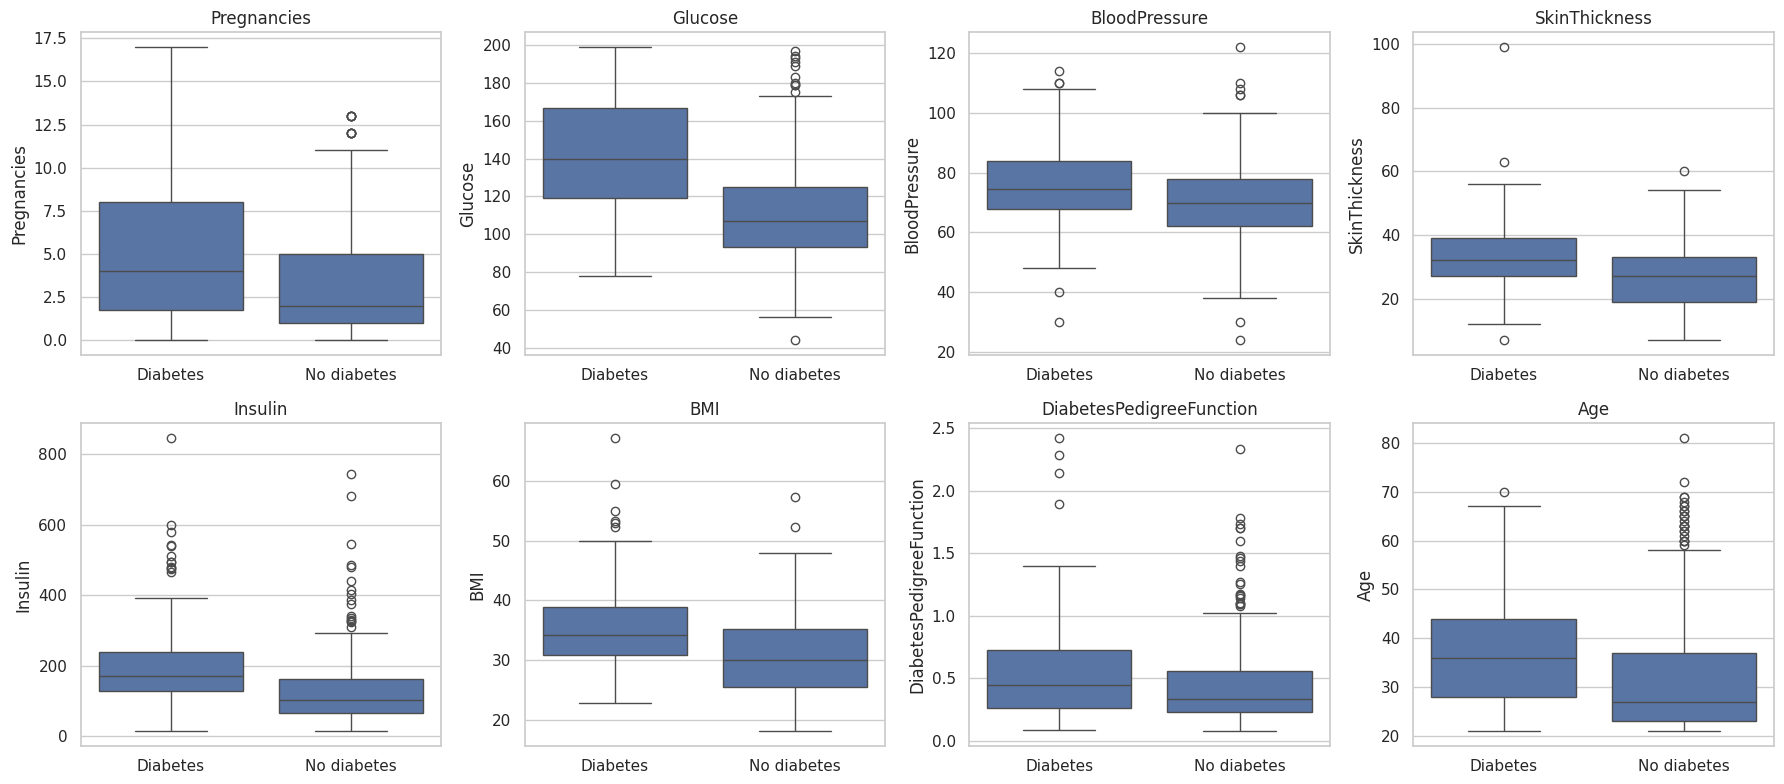

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=plot_df, x="Diagnosis", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Observation:** The median of every measurement is higher in the
diabetes group, with the largest gap for Glucose. However, the two
groups overlap strongly for all features, so no single measurement can
separate the patients on its own. This is why a model that combines
several features is useful.

### 5.3 Correlation between features
The heatmap shows how strongly each pair of variables is related. Values
close to 1 or -1 mean a strong relationship. Missing values are ignored
pair by pair.

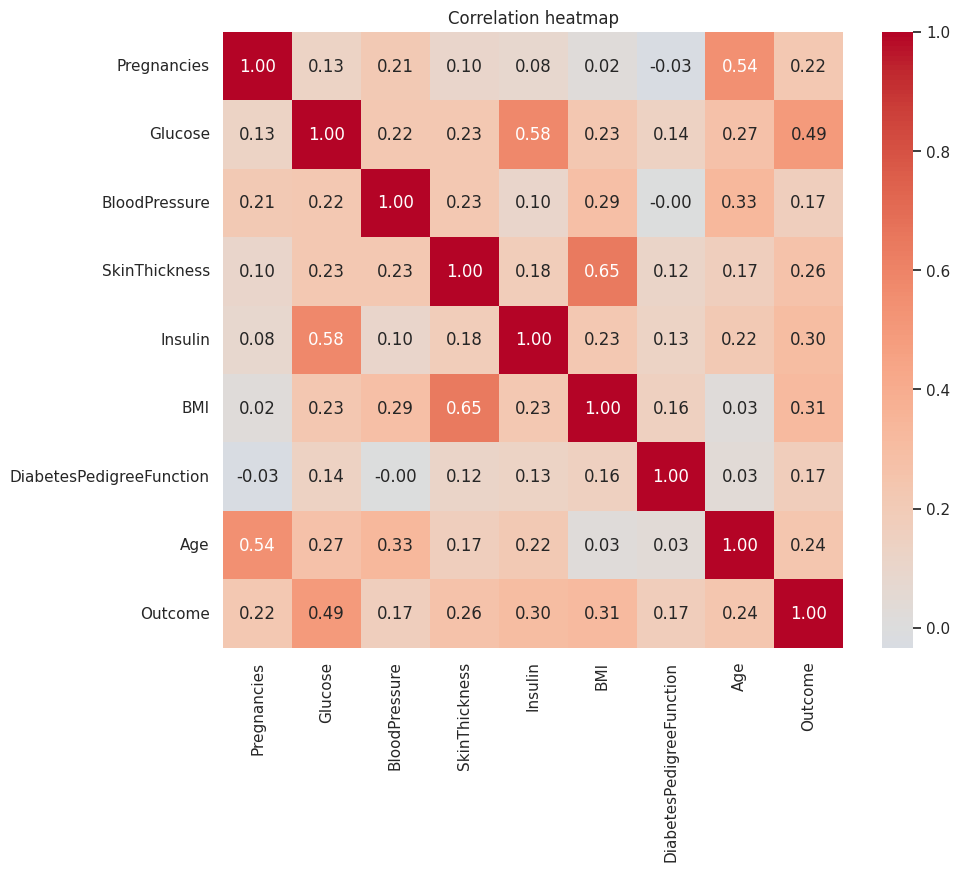

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

**Observation:** Glucose has the strongest correlation with the outcome
(0.49), followed by BMI (0.31) and Insulin (0.30). Some features are
related to each other: SkinThickness and BMI (0.65), Glucose and
Insulin (0.58), and Age and Pregnancies (0.54). Correlation shows
association only; it does not prove that one measurement causes
diabetes.

## 6. Machine Learning Models
We split the data into 80% training and 20% test sets, using a
stratified split so both parts keep the same share of diabetes cases.
Missing values are filled with the median inside a pipeline, so the
median is learned from the training data only and no information from
the test set leaks into training.

In [50]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Diabetes share in train:", round(y_train.mean(), 3))
print("Diabetes share in test:", round(y_test.mean(), 3))

Train: (614, 8) Test: (154, 8)
Diabetes share in train: 0.349
Diabetes share in test: 0.351


### 6.1 Comparing two models
We compare Logistic Regression (a simple, interpretable baseline) with
a Random Forest (a more flexible model). Both use
`class_weight="balanced"` to account for the class imbalance. We use
5-fold cross-validation on the training data and ROC AUC as the score.

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name}: ROC AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: ROC AUC = 0.844 (+/- 0.016)
Random Forest: ROC AUC = 0.823 (+/- 0.028)


**Observation:** In cross-validation, Logistic Regression (ROC AUC
0.844) scored slightly higher than Random Forest (0.823), and its
scores varied less between folds. The simple model is therefore a
strong baseline for this small dataset.

## 7. Final Evaluation on the Test Set
Each model is trained on the full training set and evaluated once on
the test set, which it has never seen. We report ROC AUC, precision,
recall, F1-score and the confusion matrix.

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    print("=" * 50)
    print(name)
    print("ROC AUC on test set:", round(roc_auc_score(y_test, proba), 3))
    print()
    print(classification_report(y_test, pred,
                                target_names=["No diabetes", "Diabetes"]))
    print("Confusion matrix (rows = true, columns = predicted):")
    print(confusion_matrix(y_test, pred))
    print()

Logistic Regression
ROC AUC on test set: 0.813

              precision    recall  f1-score   support

 No diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

Confusion matrix (rows = true, columns = predicted):
[[75 25]
 [16 38]]

Random Forest
ROC AUC on test set: 0.817

              precision    recall  f1-score   support

 No diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154

Confusion matrix (rows = true, columns = predicted):
[[84 16]
 [24 30]]



**Observation:** On the test set both models perform similarly
(accuracy 0.73 and 0.74, ROC AUC 0.813 and 0.817). They differ in the
type of mistakes they make. Logistic Regression finds more patients
with diabetes (recall 0.70, 16 missed) but raises more false alarms
(25). Random Forest raises fewer false alarms (16) but misses more
patients with diabetes (24 missed, recall 0.56). The test set has only
154 patients (54 with diabetes), so small differences between the
models should not be over-interpreted.

## 8. Conclusions and Limitations

**Conclusions**
- Glucose is the measurement most strongly linked to diabetes in this
  dataset, followed by BMI and Insulin.
- Both models reach about 0.81 ROC AUC and 73-74% accuracy on unseen
  data, a modest improvement over the 65% obtained by always predicting
  "no diabetes".
- Logistic Regression detects more patients with diabetes (recall
  0.70), while Random Forest produces fewer false alarms. In a health
  setting, missing a patient is usually more costly, which favors the
  higher recall.

**Limitations**
- The dataset is small (768 patients), so results vary with the split
  and should be confirmed with more data.
- It contains only women of Pima Indian heritage aged 21 and older, so
  the results cannot be assumed to apply to other populations.
- Many Insulin and SkinThickness values were missing and were filled
  with the median, which can hide real differences between patients.
- The models were not tuned in depth, and this analysis is for learning
  purposes only. It is not a medical tool.

**Possible next steps**
- Tune the models' hyperparameters and try other algorithms.
- Compare different ways of handling missing values.
- Repeat the analysis with a dataset from Pakistan.